# Unidade VI — Análise de Grupos

## k-medoids

**Carga estimada:** 1 hora  
**Pré-requisitos:** distâncias, k-means e avaliação básica de agrupamentos.

> **Pergunta norteadora:** como representar cada grupo por um objeto real e trabalhar com dissimilaridades que não dependem de uma média?

O k-medoids é uma alternativa particional ao k-means. O foco deste notebook é o medoide, a função de custo, o algoritmo PAM e suas vantagens e limitações.

## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- distinguir centroide, mediana e medoide;
- interpretar a função de custo do k-medoids;
- explicar atribuição e troca de representantes no PAM;
- relacionar medoides a robustez e interpretabilidade;
- reconhecer a flexibilidade de usar outras dissimilaridades;
- discutir custo computacional e alternativas por amostragem.

In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

RANDOM_STATE = 42

## 1. Do centroide ao medoide

O k-means representa cada grupo pela média, que pode não ser um objeto observado. O **k-medoids** escolhe como representante um objeto real do conjunto: o **medoide**, cuja soma de dissimilaridades aos demais objetos do grupo é mínima.

Para medoides $o_1,\ldots,o_k$, uma forma da função objetivo é:

$$E=\sum_{j=1}^{k}\sum_{p\in C_j}d(p,o_j).$$

| Aspecto | k-means | k-medoids |
|---|---|---|
| representante | média, possivelmente artificial | objeto observado |
| objetivo típico | soma de distâncias Euclidianas ao quadrado | soma de dissimilaridades |
| métrica | ligado à Euclidiana no algoritmo padrão | aceita matrizes de dissimilaridade mais gerais |
| extremos | média é mais deslocada | medoide tende a ser mais robusto |
| custo | geralmente menor | PAM examina trocas e custa mais |

Robustez não significa imunidade: outliers ainda podem formar grupos próprios ou alterar atribuições.

,valor candidato,soma das distâncias
0,1.0,8.2
1,1.2,7.6
2,1.4,7.4
3,1.6,7.6
4,8.0,26.8


Média: 2.64; medoide: 1.40


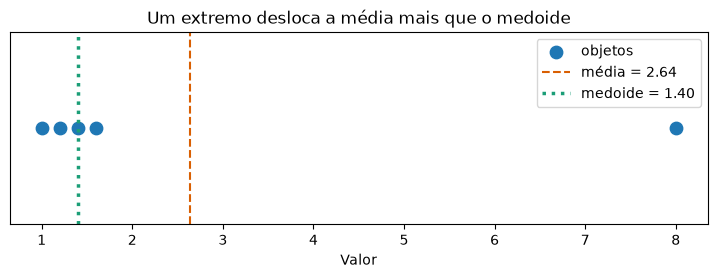

In [2]:
valores = np.array([1.0, 1.2, 1.4, 1.6, 8.0])
media = valores.mean()
custos = np.abs(valores[:, None] - valores[None, :]).sum(axis=1)
medoide = valores[np.argmin(custos)]
display(pd.DataFrame({"valor candidato": valores, "soma das distâncias": custos}))
print(f"Média: {media:.2f}; medoide: {medoide:.2f}")

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.scatter(valores, np.zeros_like(valores), s=80, label="objetos")
ax.axvline(media, color="#d95f02", linestyle="--", label=f"média = {media:.2f}")
ax.axvline(medoide, color="#1b9e77", linestyle=":", linewidth=2.5, label=f"medoide = {medoide:.2f}")
ax.set(title="Um extremo desloca a média mais que o medoide", xlabel="Valor", yticks=[])
ax.legend()
plt.show()

## 2. PAM: *Partitioning Around Medoids*

Uma forma clássica de k-medoids é o PAM:

1. escolher $k$ objetos como medoides iniciais;
2. atribuir cada objeto ao medoide mais próximo;
3. simular trocas entre um medoide e um não medoide;
4. realizar a troca que mais reduz o custo;
5. repetir até nenhuma troca melhorar a solução.

A implementação abaixo examina todas as combinações e, portanto, serve apenas a um exemplo pequeno. Ela encontra o ótimo do exemplo, não representa uma implementação escalável do PAM.

Índices dos medoides: [0, 3] | custo Manhattan: 2.7


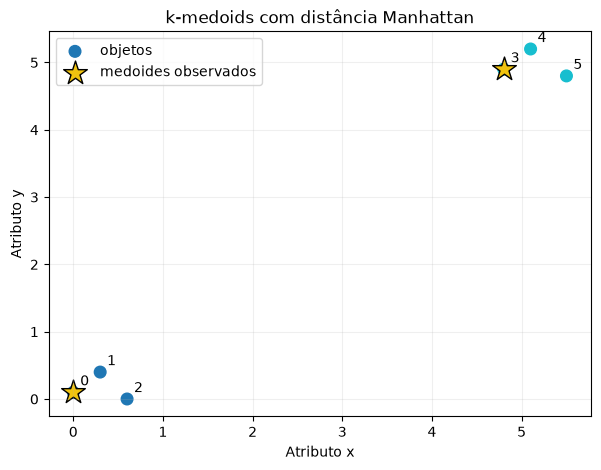

In [3]:
def kmedoids_exaustivo(X, k, metric="euclidean"):
    D = pairwise_distances(X, metric=metric)
    melhor = None
    for medoids in combinations(range(len(X)), k):
        distancias = D[:, medoids]
        labels = np.argmin(distancias, axis=1)
        custo = np.min(distancias, axis=1).sum()
        if melhor is None or custo < melhor[0]:
            melhor = (custo, np.array(medoids), labels)
    return melhor

X_med = np.array([[0.0, 0.1], [0.3, 0.4], [0.6, 0.0], [4.8, 4.9], [5.1, 5.2], [5.5, 4.8]])
custo, indices_medoides, labels_med = kmedoids_exaustivo(X_med, k=2, metric="manhattan")
print("Índices dos medoides:", indices_medoides.tolist(), "| custo Manhattan:", round(custo, 2))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_med[:, 0], X_med[:, 1], c=labels_med, cmap="tab10", s=70, label="objetos")
ax.scatter(X_med[indices_medoides, 0], X_med[indices_medoides, 1], marker="*", s=320, color="#f1c40f", edgecolor="black", label="medoides observados")
for i, (x, y) in enumerate(X_med): ax.annotate(str(i), (x, y), xytext=(5, 5), textcoords="offset points")
ax.set(title="k-medoids com distância Manhattan", xlabel="Atributo x", ylabel="Atributo y")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

### Quando o medoide é especialmente interessante?

Como o representante precisa ser um objeto e o algoritmo trabalha com dissimilaridades, k-medoids pode usar Manhattan, Gower ou uma distância definida para sequências, desde que a matriz seja calculada de forma coerente. Isso ajuda com atributos mistos e objetos sem média natural.

A flexibilidade não autoriza escolher qualquer distância: pesos, escala, valores ausentes e interpretação continuam definindo a noção de grupo. PAM também é mais caro que k-means em conjuntos grandes; CLARA e outras aproximações usam amostragem para ganhar escala.

## 3. Quando considerar k-medoids

O método é especialmente útil quando o representante deve ser um objeto observado, quando a média não possui interpretação ou quando se deseja empregar uma dissimilaridade como Manhattan ou Gower.

Em comparação com k-means, ganha robustez e flexibilidade, mas paga maior custo computacional. Ainda exige escolher o número de grupos, preparar atributos, avaliar estabilidade e interpretar os representantes no domínio.

## 4. Atividades

**U06-NB04-V01.** Para [1, 2, 3, 20], calcule a média e identifique todos os medoides possíveis pela soma das distâncias absolutas. Explique a diferença.

**U06-NB04-E01.** Para os pontos unidimensionais [0, 1, 2, 9, 10] e k=2, compare os pares de medoides (0,9), (1,9) e (1,10) pela soma das distâncias ao representante mais próximo. Qual é melhor? Há empate?

**U06-NB04-E02.** Compare k-means e k-medoids para agrupar hospitais descritos por atributos mistos usando distância de Gower. Qual é diretamente compatível com a proposta e quais decisões ainda precisam ser tomadas?

## 5. Síntese

- O medoide é um objeto observado que minimiza dissimilaridades dentro do grupo.
- PAM melhora a solução por trocas entre medoides e não medoides.
- Medoides tendem a ser menos influenciados por extremos que médias, mas não são imunes a ruído.
- Dissimilaridades gerais ampliam aplicações, desde que pesos e atributos sejam justificáveis.
- O custo do PAM motiva amostragem e aproximações em grandes bases.

## Referências

- HAN, J.; PEI, J.; TONG, H. *Data Mining: Concepts and Techniques*. 4. ed. Morgan Kaufmann, 2023. Seção 8.2.1.
- KAUFMAN, L.; ROUSSEEUW, P. J. *Finding Groups in Data: An Introduction to Cluster Analysis*. Wiley, 1990.

Os dados, a implementação exaustiva e as figuras são autorais e produzidos para fins didáticos.